# Ch08-2 합성곱 신경망을 사용한 이미지 분류

케라스를 사용하면, 합성곱, 패딩, 풀링 크기를 직접 계산할 필요가 없다.   
계산은 케라스 api에서 해주고, 사용자는 직관적으로 신경망을 설계할 수 있다.      

## 1. 패션 MNIST 데이터 불러오기

**<전처리>**
- 데이터 스케일을 0 ~ 255 사이에서 0 ~ 1 사이로 바꾸고 훈련 세트와 검증 세트로 나눈다.      
- 그러나, 완전 연결 신경망에서는 입력 이미지를 밀집층에 연결하기 위해 일렬로 펼쳐야 했으나, 합성곱 신경망은 2차원 이미지를 그대로 사용하므로 일렬로 펼치지 않아도 된다.   


- 또 그러나 입력 이미지는 항상 깊이 (채널) 차원이 있어야 함.        



In [3]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

2025-11-27 16:50:17.294638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-27 16:50:17.320952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764229817.347448  171253 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764229817.360733  171253 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-27 16:50:17.388484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

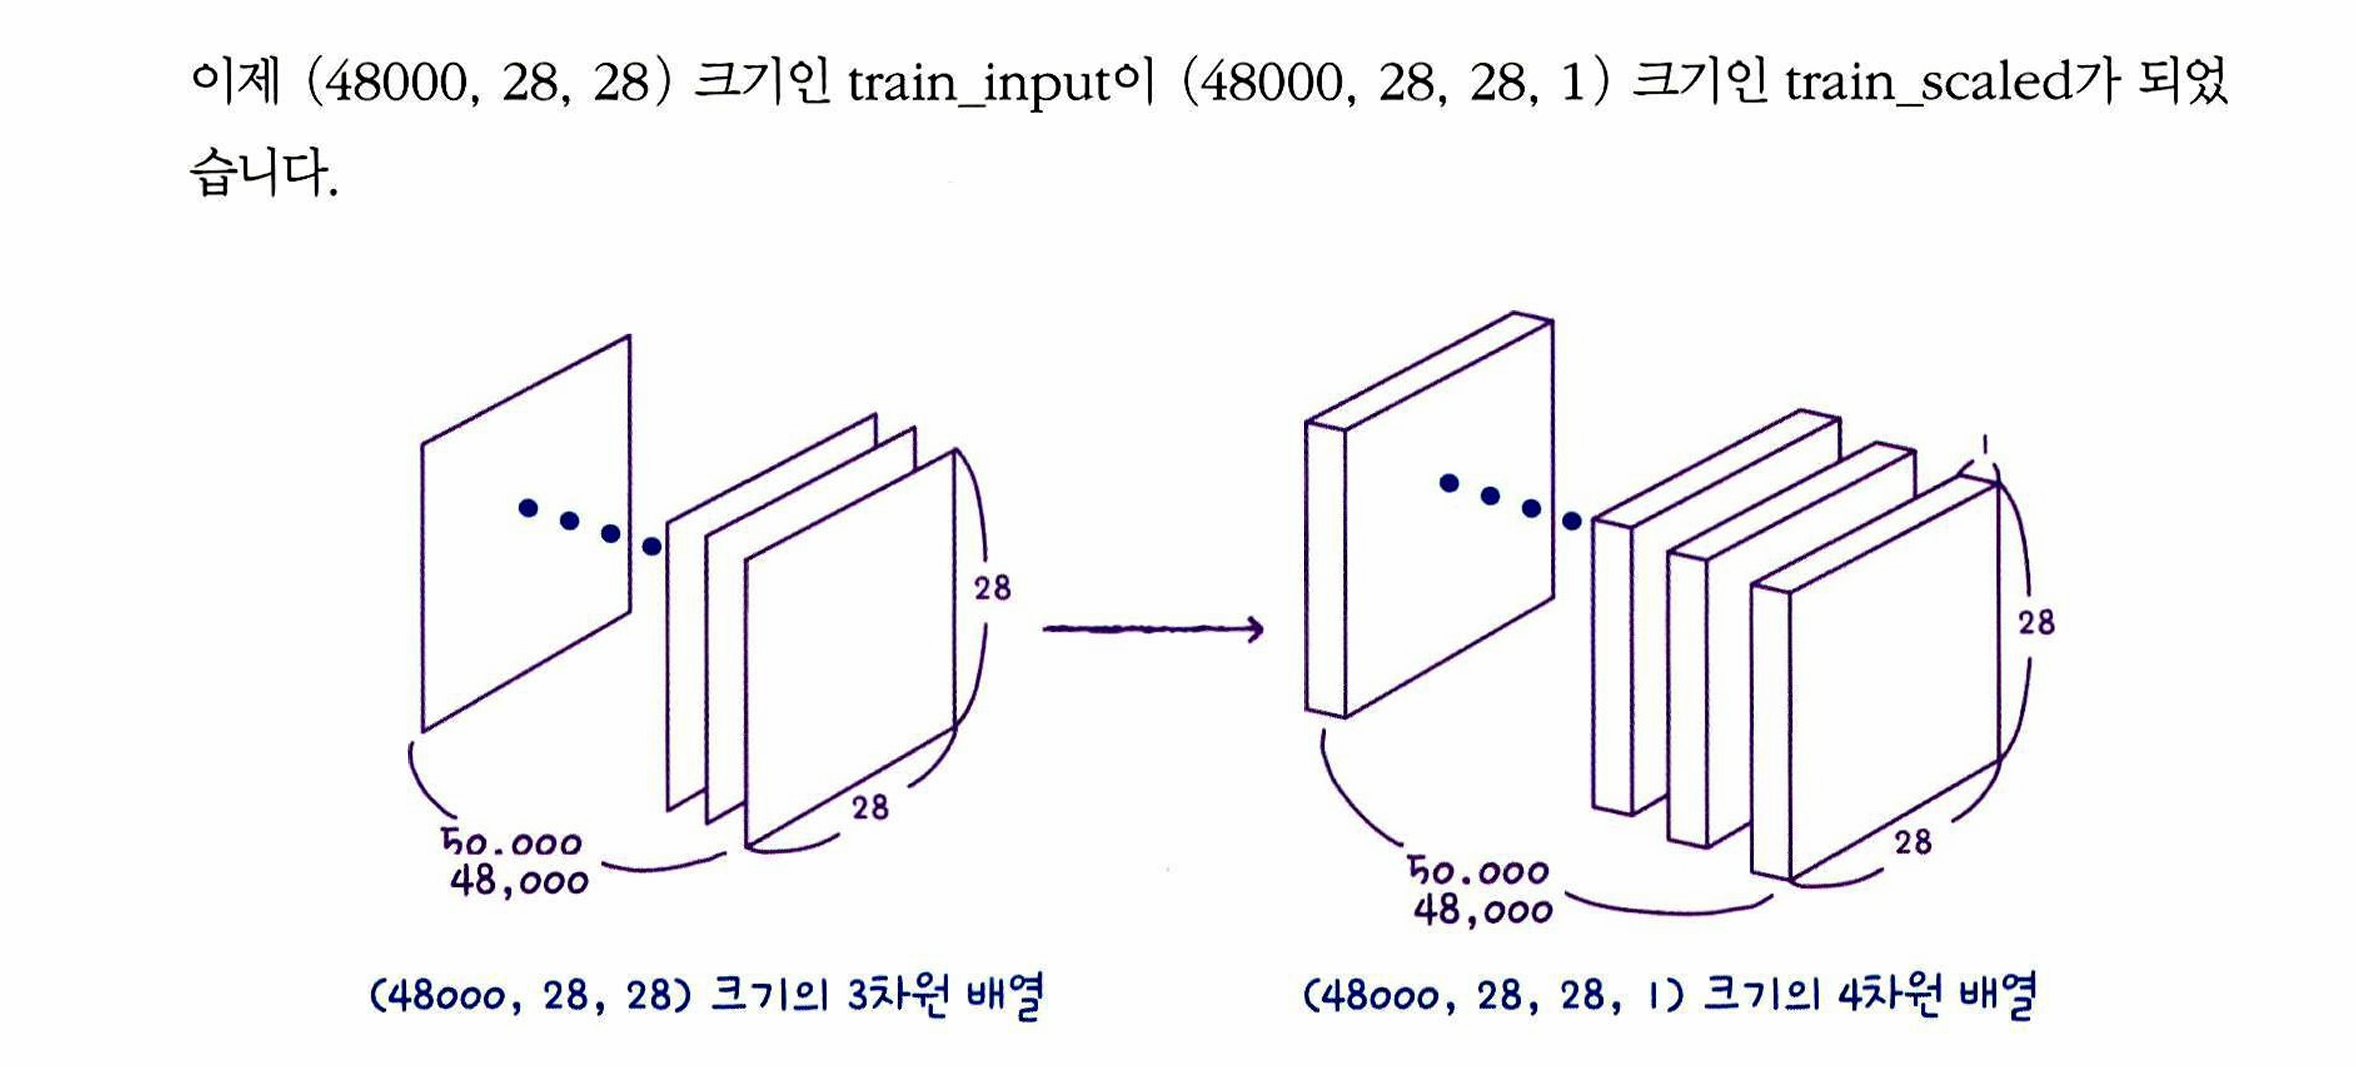

## 2. 합성곱 신경망 만들기

합성곱 신경망 구조 = 합성곱 층으로 이미지에서 특성을 감지 -> 밀집층으로 클래스에 다른 분류 확률 계산        

sequential 클래스의 객체를 만들고 첫 번째 합성곱 층인 Conv2D를 추가. 

In [4]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',padding='same')) #32개의 필터, 커널 크기 (3, 3) , 렐루 활성화 함수, 세임 패딩 사용

I0000 00:00:1764229823.553697  171253 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
model.add(keras.layers.MaxPooling2D(2))

`MaxPooling2D` 최대 풀링        
`AveragePooling2D` 평균 풀링    
- (2,2) 풀링을 사용하면 맵의 크기는 절반응로 줄어듦       
- 필터를 32개 사용하므로 특성 맵의 깊이는 32가 됨       

따라서, 특성 맵의 크기는 (14, 14, 32)

In [6]:
# 두 번째 합성곱-풀링 층을 추가. 필터 개수를 64개로 늘림

model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

또 절반으로 줄어서 (7, 7, 64)
특성맵을 일렬로 펼치기 
- 마지막에 10개의 뉴런을 가진 밀집 출력층에서 확률을 계산하기 위해      
- Flatten 클래스 -> Dense 은닉층 -> Dense 출력층 순서대로 구성

In [7]:

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu')) #은닉층
model.add(keras.layers.Dropout(0.4)) #드롭아웃
model.add(keras.layers.Dense(10, activation='softmax')) #출력층

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**깊이 :**          
- 첫 번째 합성곱 층 -> 32 -> 두 번째 합성곱 층 -> 64            

**가로세로 크기 :**      
- 첫 번째 풀링 층 - > 절반 -> 두 번째 풀링층 -> 다시 절반       

**최종 :** (7, 7, 64)           


**<모델 파라미터>**
- 첫 번째 합성곱 층 : 32개 필터, (3,3)크기, 깊이 1, 필터마다 하나의 절편        
  = 3 x 3 x 1 x 1 x 32 + 32 = 320개         

- 두 번째 합성곱 층 : 64개 필터, 크기 (3,3), 깊이 32, 필터마다 하나의 절편      
  = 3 x 3 x 32 x 64 + 64 = 18,496개     



**<배열의 크기>**

Flatten 클래스에서 (7, 7, 64) 크기의 특성 맵을 1차원 배열로 펼치면 (3136,) 크기의 배열      
-> 100개의 뉴런과 연결 -> 3,136 x 100 + 100 = 313,700개     



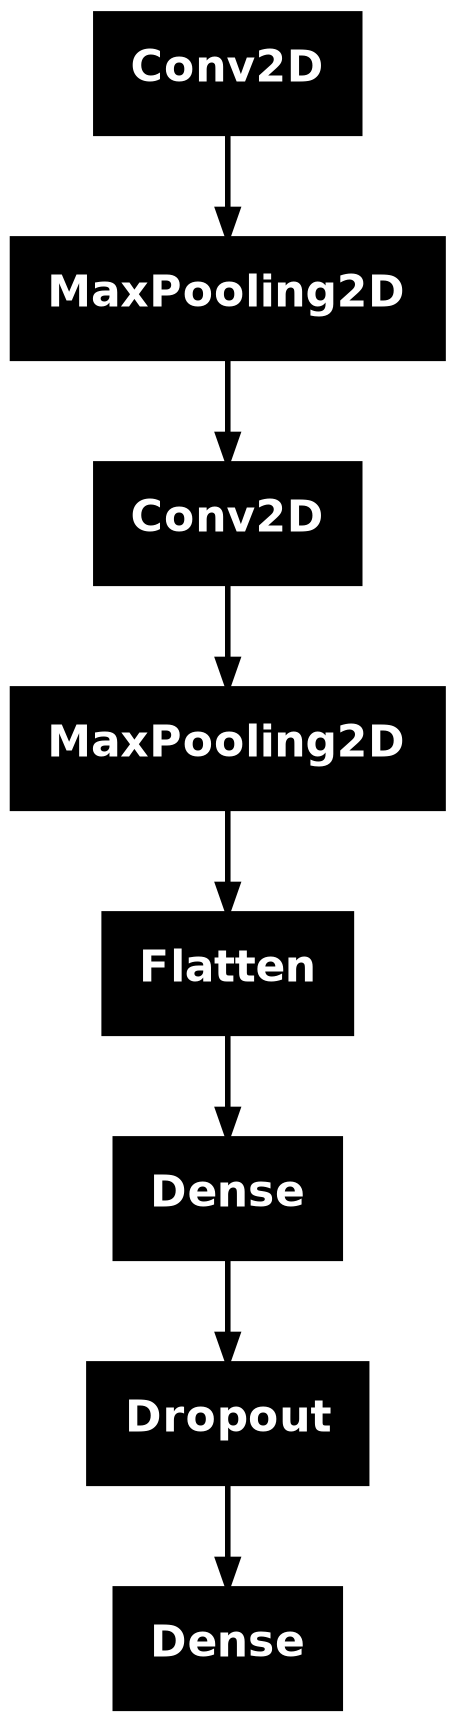

In [9]:
#각 층의 구성을 그림으로 표현
keras.utils.plot_model(model)

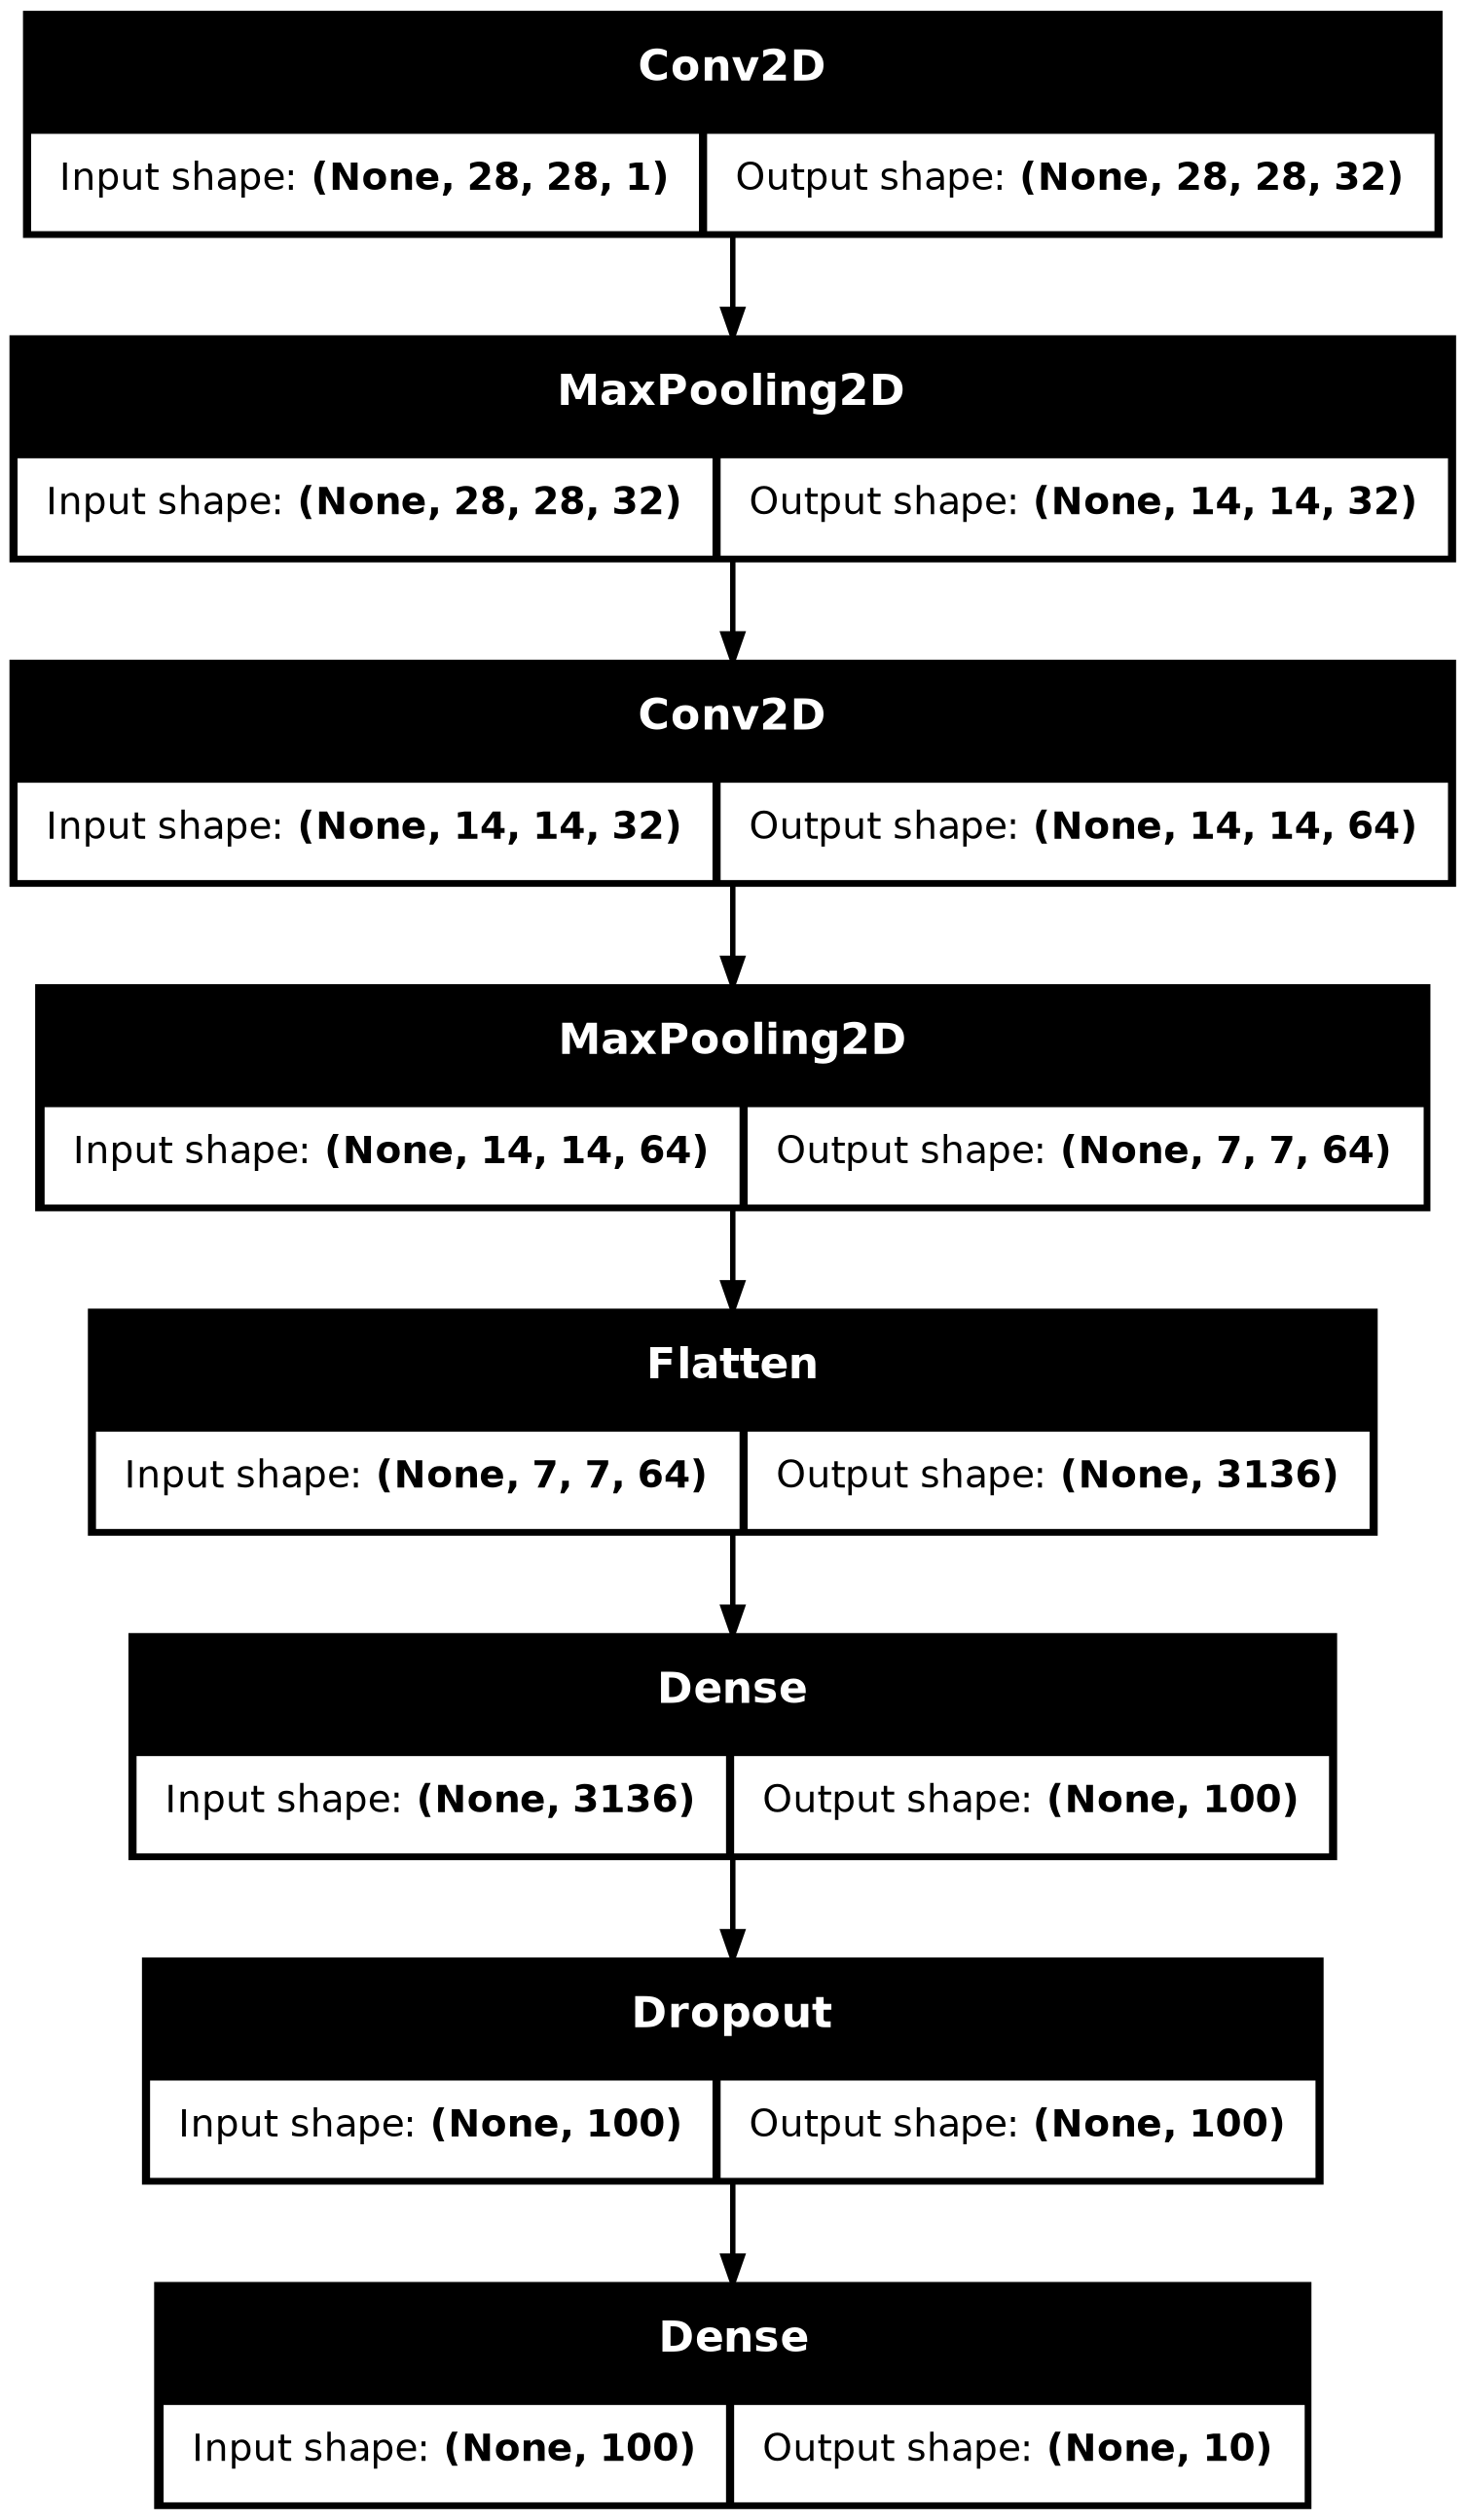

In [10]:
keras.utils.plot_model(model, show_shapes=True) #그림에 입력과 출력의 크기를 표시

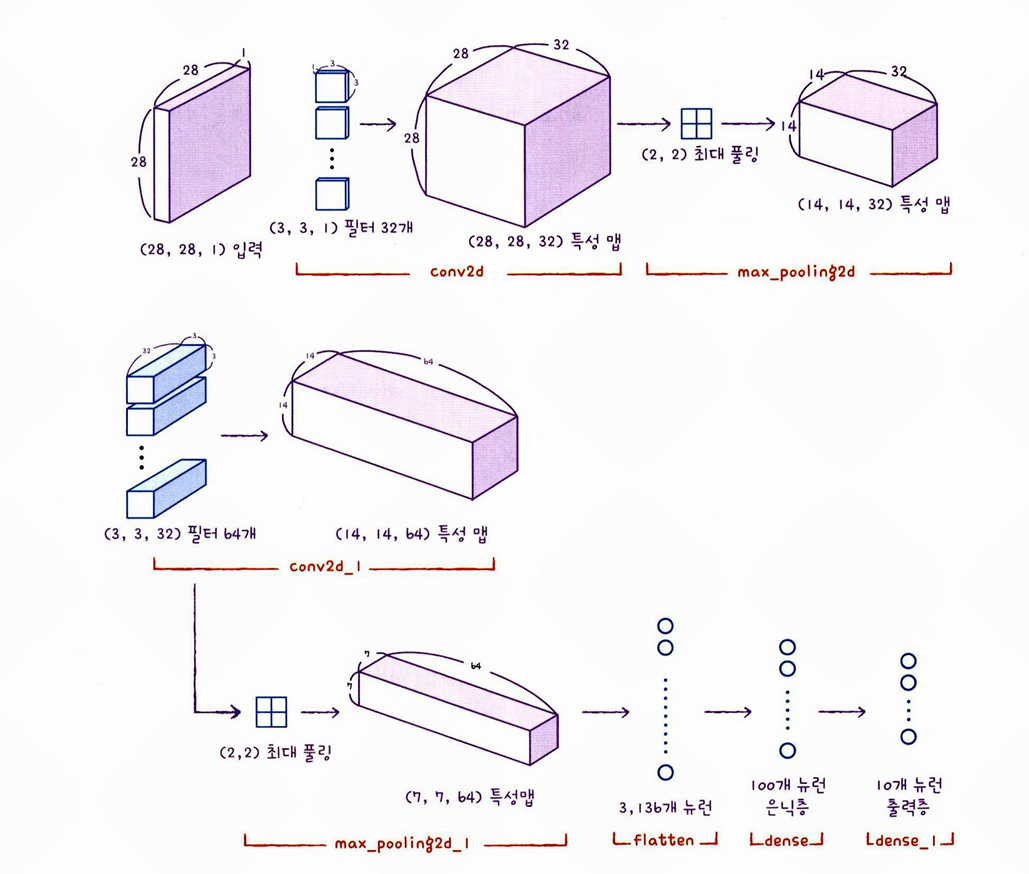

## 3. 모델 컴파일과 훈련

keras api의 장점은 딥러닝 모델의 종류나 구성 방식에 상관 없이 컴파일고 ㅏ훈련 과정이 같다는 장점이 있다.        


In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)
early_stopping_cb=keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20


I0000 00:00:1764229826.481124  171493 service.cc:148] XLA service 0x7bb9b4004d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764229826.481222  171493 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 4GB Laptop GPU, Compute Capability 8.6
2025-11-27 16:50:26.510592: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764229826.671860  171493 cuda_dnn.cc:529] Loaded cuDNN version 91501


  28/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3256 - loss: 1.9659 

I0000 00:00:1764229828.675379  171493 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7411 - loss: 0.7295 - val_accuracy: 0.8797 - val_loss: 0.3271
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8706 - loss: 0.3606 - val_accuracy: 0.8977 - val_loss: 0.2776
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8911 - loss: 0.3014 - val_accuracy: 0.9046 - val_loss: 0.2518
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9003 - loss: 0.2736 - val_accuracy: 0.9118 - val_loss: 0.2432
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9126 - loss: 0.2461 - val_accuracy: 0.9131 - val_loss: 0.2431
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9185 - loss: 0.2215 - val_accuracy: 0.9162 - val_loss: 0.2276
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9227 - loss: 0.2049 - val_accuracy: 0.9186 - val_loss: 0.2226
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9302 - loss: 0.1868 - val

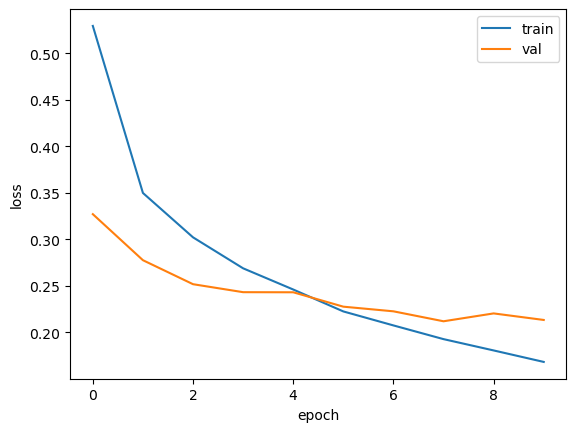

In [13]:
#손실그래프를 그려서 조기 종료가 잘 실행 되었는가 확인
import matplotlib.pyplot as plt

plt. plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

EarlyStopping 클래스에서 restore_best_weights 매개변수를 True로 지정했으므로 현재 model 객체가 최적의 모델 파라미터로 복원되어 dlTek.       
즉, ModelCheckpoint 콜백이 저장한 best-cnn-model.keras 파일을 다시 읽을 필요가 없다.    

In [ ]:
#성능 평가
model.evaluate(val_scaled, val_target) #6번째 모델과 유사한 성능

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9259 - loss: 0.2066


[0.2118966281414032, 0.9242500066757202]

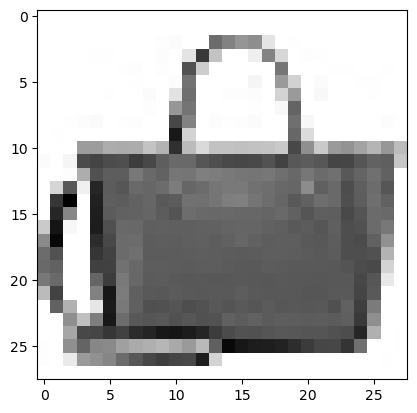

In [15]:
#predict를 사용해 훈련된 모델을 사용하여 새로운 데이터에 대해 예측을 만들어보기
#편의상 검증 세트의 첫 번째 샘플을 처음 본 이미지라고 가정
#맷플롯립에서는 흑백 이미지에 깊이 차원이 없으므로 , (28, 28, 1)을 (28, 28)로 바꾸어 출력
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [16]:
#모델이 이 이미지에 대하여 어떤 예측을 만드는지 확인
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
[[5.8955758e-19 7.0365837e-29 6.9355883e-20 2.1068768e-19 1.2815382e-17
  8.6911867e-19 5.3231446e-18 1.1321950e-20 1.0000000e+00 1.9849927e-23]]


제일 큰 확률은 9번째.       
(다른 숫자들은 0.00000000000x)          
출력값 중에서 e 문자는 지수 표현을 의미합니다. 예를 들어 5e3은 5 x 103이고 5e—3은 5 x 10-입니다

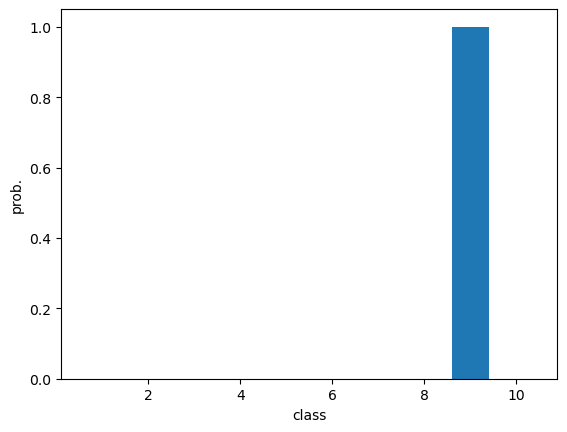

In [17]:
#막대 그래프로 그려보기

plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [23]:
#각 클래스 이름 붙이기
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [24]:
import numpy as np 

print(classes[np.argmax(preds)])

가방


In [25]:
# 맨 처음에 떼놓은 테스트 세트로 합성곱 신경망의 일반화 성능 측정
test_scaled = test_input.reshape(-1, 28, 28, 1) /255.0

In [26]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9167 - loss: 0.2409


[0.23431530594825745, 0.9165999889373779]

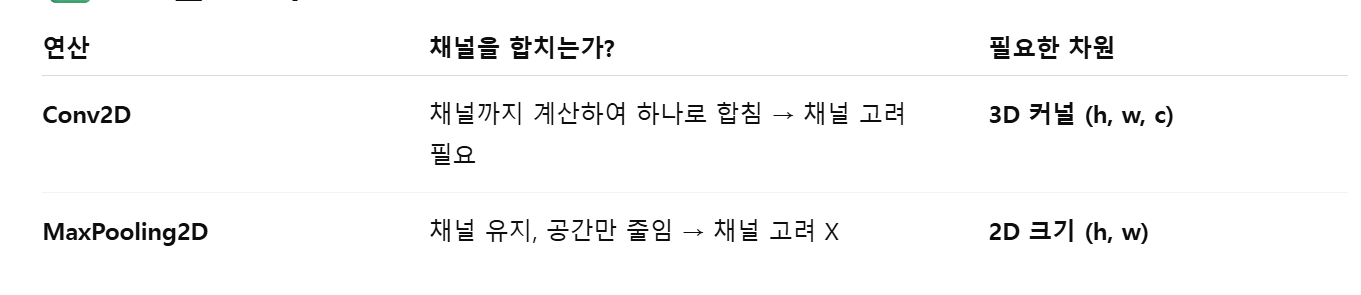
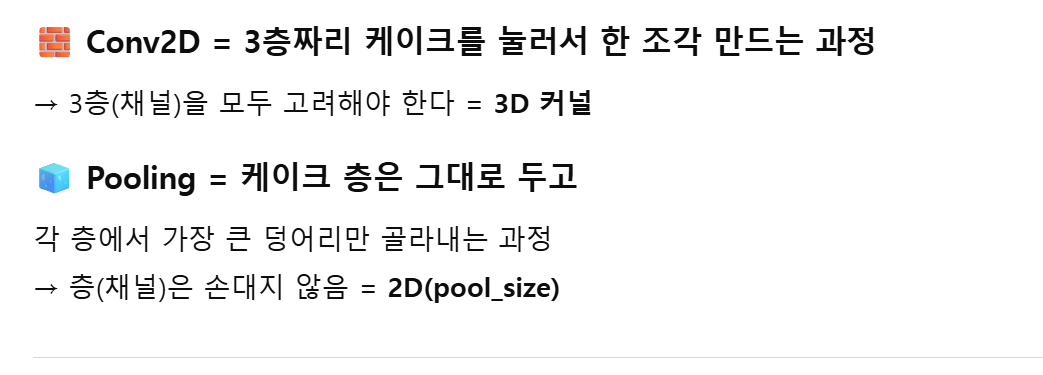